# NYPD Arrest Data Analysis

## Research Question
How do arrest severity patterns differ between Brooklyn and Manhattan in 2026 NYPD arrest data?

## Project Overview
This project analyzes NYPD arrest data from 2026 to compare arrest severity patterns between Brooklyn and Manhattan. The analysis focuses on felony, misdemeanor, and violation arrest categories. The project includes data cleaning, descriptive statistics, data visualization, and a discussion of possible bias within the dataset.

In [1]:
!mamba install pandas numpy matplotlib seaborn scikit-learn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.3880999999046326 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.4.22                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.13                          pyhcf101f3_0                  conda-forge                   
+ joblib                    

In [2]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
# LOAD DATASET
df = pd.read_csv ('NYPD_Arrest_Data_(Year_to_Date)_20260509.csv')

## Initial Data Exploration

The dataset was explored to understand its structure, identify missing values, inspect data types, and examine the categories used in important columns such as arrest severity and borough location.

In [4]:
# Display first 5 rows
df.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,318451126,01/06/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,M,BLACK,1020232,210719,40.744989,-73.870145,POINT (-73.870145 40.744989)
1,318308486,01/03/2026,203.0,"TRESPASS 3, CRIMINAL",352.0,CRIMINAL TRESPASS,PL 140100G,M,K,77,1,25-44,M,BLACK,1003358,182945,40.668798,-73.931120,POINT (-73.93112014 40.66879784)
2,318550123,01/08/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,B,48,0,25-44,M,WHITE HISPANIC,1011780,246837,40.844152,-73.900500,POINT (-73.9005 40.844152)
3,318580867,01/07/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102B,F,M,28,0,(null),(null),BLACK,999788,233328,40.807102,-73.943874,POINT (-73.943874 40.807102)
4,318684449,01/10/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102A,F,B,45,0,<18,F,BLACK,1031351,254245,40.864401,-73.829711,POINT (-73.829711 40.864401)


In [5]:
# Display dataset structure and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 69305 entries, 0 to 69304
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ARREST_KEY         69305 non-null  int64  
 1   ARREST_DATE        69305 non-null  str    
 2   PD_CD              69303 non-null  float64
 3   PD_DESC            69305 non-null  str    
 4   KY_CD              69293 non-null  float64
 5   OFNS_DESC          69305 non-null  str    
 6   LAW_CODE           69305 non-null  str    
 7   LAW_CAT_CD         69038 non-null  str    
 8   ARREST_BORO        69305 non-null  str    
 9   ARREST_PRECINCT    69305 non-null  int64  
 10  JURISDICTION_CODE  69305 non-null  int64  
 11  AGE_GROUP          69305 non-null  str    
 12  PERP_SEX           69305 non-null  str    
 13  PERP_RACE          69305 non-null  str    
 14  X_COORD_CD         69305 non-null  int64  
 15  Y_COORD_CD         69305 non-null  int64  
 16  Latitude           69305 non-null

## Missing Value Inspection

The dataset contained both standard missing values (`NaN`) and placeholder string values labeled `(null)`. A combined summary table was created to identify columns affected by missing or incomplete data before cleaning.

In [6]:
# MISSING VALUE SUMMARY
missing_summary = pd.DataFrame({
    'NaN_Count': df.isnull().sum(),
    'Null_String_Count': (df == '(null)').sum()
})

# Add total problematic values
missing_summary['Total_Missing_Like'] = (
    missing_summary['NaN_Count'] +
    missing_summary['Null_String_Count']
)

# Display results
missing_summary.sort_values(
    by='Total_Missing_Like',
    ascending=False
)

,NaN_Count,Null_String_Count,Total_Missing_Like
AGE_GROUP,0,16933,16933
PERP_SEX,0,16933,16933
LAW_CAT_CD,267,2,269
PD_DESC,0,12,12
KY_CD,12,0,12
OFNS_DESC,0,12,12
PD_CD,2,0,2
LAW_CODE,0,2,2
ARREST_KEY,0,0,0
X_COORD_CD,0,0,0


Basic Category Inspection

In [7]:
# Unique arrest severity categories
df['LAW_CAT_CD'].value_counts(dropna=False)

LAW_CAT_CD
M         40761
F         26889
V          1123
NaN         267
9           210
I            53
(null)        2
Name: count, dtype: int64

In [8]:
# Borough categories
df['ARREST_BORO'].value_counts()

ARREST_BORO
K    21111
M    15870
B    15613
Q    14160
S     2551
Name: count, dtype: int64

## Selecting Relevant Columns

The original dataset contained many variables that were not necessary for this analysis. To simplify the project and improve readability, only columns relevant to borough comparison and arrest severity analysis were retained.

In [9]:
# SELECT RELEVANT COLUMNS
df1 = df[[
    'ARREST_BORO',
    'LAW_CAT_CD',
    'OFNS_DESC',
    'ARREST_DATE'
]].copy()

df1.head()

,ARREST_BORO,LAW_CAT_CD,OFNS_DESC,ARREST_DATE
0,Q,F,FELONY ASSAULT,01/06/2026
1,K,M,CRIMINAL TRESPASS,01/03/2026
2,B,F,FELONY ASSAULT,01/08/2026
3,M,F,ROBBERY,01/07/2026
4,B,F,ROBBERY,01/10/2026


# Data Cleaning

Several preprocessing steps were performed before analysis. Placeholder `(null)` values were converted into proper missing values (`NaN`). Missing rows were removed and invalid arrest severity categories were filtered out to improve analysis quality and ensure accurate comparisons between boroughs. Finally, the arrest date column was converted into datetime format.

In [10]:
# Convert '(null)' into proper missing values
df1.replace('(null)', np.nan, inplace=True)

,ARREST_BORO,LAW_CAT_CD,OFNS_DESC,ARREST_DATE
0,Q,F,FELONY ASSAULT,01/06/2026
1,K,M,CRIMINAL TRESPASS,01/03/2026
2,B,F,FELONY ASSAULT,01/08/2026
3,M,F,ROBBERY,01/07/2026
4,B,F,ROBBERY,01/10/2026
...,...,...,...,...
69300,K,M,ASSAULT 3 & RELATED OFFENSES,03/20/2026
69301,B,F,BURGLARY,03/13/2026
69302,M,M,CRIMINAL MISCHIEF & RELATED OF,03/05/2026
69303,Q,F,MISCELLANEOUS PENAL LAW,03/27/2026


In [11]:
# Remove rows with missing values
df1.dropna(inplace=True)

In [12]:
# Convert arrest date to datetime format
df1['ARREST_DATE'] = pd.to_datetime(df1['ARREST_DATE'])

In [13]:
# Keep only:
# - valid severity categories
# - Brooklyn and Manhattan arrests

comparison_df = df1[
    (df1['LAW_CAT_CD'].isin(['F', 'M', 'V'])) &
    (df1['ARREST_BORO'].isin(['K', 'M']))
].copy()

CREATE READABLE COLUMNS

In [14]:
# Borough mapping
boro_map = {
    'K': 'Brooklyn',
    'M': 'Manhattan'
}

comparison_df['BOROUGH'] = comparison_df[
    'ARREST_BORO'
].map(boro_map)

In [15]:
# Severity mapping
severity_map = {
    'F': 'Felony',
    'M': 'Misdemeanor',
    'V': 'Violation'
}

comparison_df['SEVERITY'] = comparison_df[
    'LAW_CAT_CD'
].map(severity_map)

In [16]:
# Preview cleaned dataset
comparison_df.head()

,ARREST_BORO,LAW_CAT_CD,OFNS_DESC,ARREST_DATE,BOROUGH,SEVERITY
1,K,M,CRIMINAL TRESPASS,2026-01-03,Brooklyn,Misdemeanor
3,M,F,ROBBERY,2026-01-07,Manhattan,Felony
5,M,F,ARSON,2026-01-12,Manhattan,Felony
10,K,F,ROBBERY,2026-01-27,Brooklyn,Felony
13,K,F,FELONY ASSAULT,2026-02-04,Brooklyn,Felony


In [17]:
# Check cleaned data
comparison_df.isnull().sum()

ARREST_BORO    0
LAW_CAT_CD     0
OFNS_DESC      0
ARREST_DATE    0
BOROUGH        0
SEVERITY       0
dtype: int64

# Descriptive Statistics

The following statistics summarize arrest patterns between Brooklyn and Manhattan. The analysis compares total arrest counts and arrest severity percentages across both boroughs.

In [18]:
# TOTAL ARREST COUNTS
comparison_df['BOROUGH'].value_counts().to_frame(name='count')

,count
BOROUGH,
Brooklyn,21027
Manhattan,15684


In [19]:
# ARREST SEVERITY PERCENTAGES
severity_table = pd.crosstab(
    comparison_df['BOROUGH'],
    comparison_df['SEVERITY'],
    normalize='index'
) * 100

severity_table

SEVERITY,Felony,Misdemeanor,Violation
BOROUGH,,,
Brooklyn,39.93437,56.617682,3.447948
Manhattan,38.03239,61.553175,0.414435


Interpretation of Results

The descriptive statistics show that misdemeanor arrests represented the majority of arrests in both Brooklyn and Manhattan. Brooklyn recorded more total arrests overall and showed slightly higher proportions of felony and violation arrests compared to Manhattan. Manhattan had a larger proportion of misdemeanor arrests, while violation arrests were relatively rare in Manhattan. These results suggest that arrest severity patterns differed between the two boroughs during the analyzed period.

# VISUALIZATION

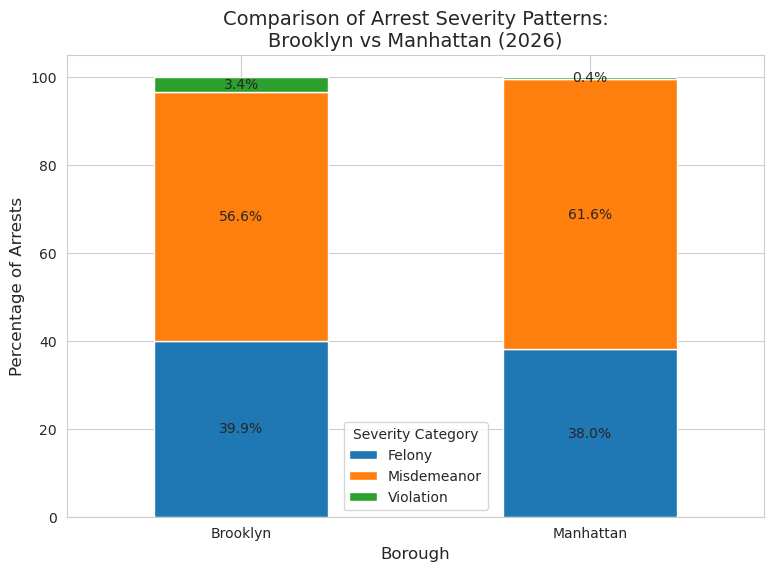

In [20]:
sns.set_style("whitegrid")

ax = severity_table.plot(
    kind='bar',
    stacked=True,
    figsize=(9,6)
)

# Chart title and labels
plt.title(
    'Comparison of Arrest Severity Patterns:\nBrooklyn vs Manhattan (2026)',
    fontsize=14
)

plt.xlabel('Borough', fontsize=12)

plt.ylabel('Percentage of Arrests', fontsize=12)

plt.legend(title='Severity Category')

plt.xticks(rotation=0)

# ADD PERCENT LABELS
for container in ax.containers:

    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center',
        fontsize=10
    )

plt.show()

# Conclusion

This analysis found that arrest severity patterns differed between Brooklyn and Manhattan in the 2026 NYPD arrest dataset. Misdemeanor arrests were the largest category in both boroughs. Brooklyn showed slightly higher proportions of felony and violation arrests, while Manhattan had a higher proportion of misdemeanor arrests. However, arrest data reflects policing practices and enforcement activity rather than actual crime rates alone. Bias may exist due to differences in police presence, neighborhood demographics, enforcement priorities, and reporting practices across boroughs.